In [18]:
pip install pandas numpy matplotlib seaborn scipy

  Using cached scipy-1.17.0-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.0-cp313-cp313-win_amd64.whl (36.3 MB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency
import os
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import math
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    log_loss,
    precision_score,
    recall_score,
    f1_score
)

from joblib import dump
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from joblib import load
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.metrics import roc_auc_score
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [3]:
df = pd.read_csv(r"D:\IPP_study\Machinelearning\project\criteo-uplift-v2.1.csv")

print(df.head())
print(df.shape)

          f0         f1        f2        f3         f4        f5        f6  \
0  12.616365  10.059654  8.976429  4.679882  10.280525  4.115453  0.294443   
1  12.616365  10.059654  9.002689  4.679882  10.280525  4.115453  0.294443   
2  12.616365  10.059654  8.964775  4.679882  10.280525  4.115453  0.294443   
3  12.616365  10.059654  9.002801  4.679882  10.280525  4.115453  0.294443   
4  12.616365  10.059654  9.037999  4.679882  10.280525  4.115453  0.294443   

         f7        f8         f9       f10       f11  treatment  conversion  \
0  4.833815  3.955396  13.190056  5.300375 -0.168679          1           0   
1  4.833815  3.955396  13.190056  5.300375 -0.168679          1           0   
2  4.833815  3.955396  13.190056  5.300375 -0.168679          1           0   
3  4.833815  3.955396  13.190056  5.300375 -0.168679          1           0   
4  4.833815  3.955396  13.190056  5.300375 -0.168679          1           0   

   visit  exposure  
0      0         0  
1      0      

In [3]:
# View missing values
nan_count = df.isna().sum()

nan_count[nan_count > 0].sort_values(ascending=False)
nan_count = df.isna().sum()

nan_count[nan_count > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [4]:
# View overall data allocation
# Total sample size
total = len(df)

print(f"Total samples: {total:,}\n")

# Quantity Statistics
count = df["conversion"].value_counts().sort_index()
print("Conversion count:")
print(count)

print("\nConversion proportion:")
# Percentage Statistics
ratio = df["conversion"].value_counts(normalize=True).sort_index()
print(ratio)

print("\nFormatted summary:")
for k in count.index:
    print(
        f"conversion = {k}: "
        f"{count[k]:,} samples "
        f"({ratio[k] * 100:.4f}%)"
    )

Total samples: 13,979,592

Conversion count:
conversion
0    13938818
1       40774
Name: count, dtype: int64

Conversion proportion:
conversion
0    0.997083
1    0.002917
Name: proportion, dtype: float64

Formatted summary:
conversion = 0: 13,938,818 samples (99.7083%)
conversion = 1: 40,774 samples (0.2917%)


In [7]:
# Divide the test set
RANDOM_STATE = 42
FRACTION = 1 / 5  # 抽 1/5

# Split by treatment
df_t0 = df[df["treatment"] == 0]
df_t1 = df[df["treatment"] == 1]

print(f"treatment=0 total: {len(df_t0):,}")
print(f"treatment=1 total: {len(df_t1):,}")

# Stratified sampling by conversion within each treatment
def stratified_sample(df_sub, fraction, random_state):
    sample_size = int(len(df_sub) * fraction)

    sampled_df, _ = train_test_split(
        df_sub,
        train_size=sample_size,
        stratify=df_sub["conversion"],
        random_state=random_state
    )
    return sampled_df

df_t0_sample = stratified_sample(df_t0, FRACTION, RANDOM_STATE)
df_t1_sample = stratified_sample(df_t1, FRACTION, RANDOM_STATE)

# Distributed Validation
def check_distribution(name, original, sampled):
    print(f"\n{name}")
    print("Original conversion ratio:")
    print(original["conversion"].value_counts(normalize=True))

    print("Sampled conversion ratio:")
    print(sampled["conversion"].value_counts(normalize=True))

check_distribution("Treatment = 0", df_t0, df_t0_sample)
check_distribution("Treatment = 1", df_t1, df_t1_sample)

# Save results
df_t0_sample.to_csv(
    r"D:\IPP_study\Machinelearning\project\data\treatment_0_sample_1_5.csv",
    index=False
)

df_t1_sample.to_csv(
    r"D:\IPP_study\Machinelearning\project\data\treatment_1_sample_1_5.csv",
    index=False
)

print("\n✅ Sampling finished and files saved.")

treatment=0 total: 2,096,937
treatment=1 total: 11,882,655

Treatment = 0
Original conversion ratio:
conversion
0    0.998062
1    0.001938
Name: proportion, dtype: float64
Sampled conversion ratio:
conversion
0    0.998061
1    0.001939
Name: proportion, dtype: float64

Treatment = 1
Original conversion ratio:
conversion
0    0.996911
1    0.003089
Name: proportion, dtype: float64
Sampled conversion ratio:
conversion
0    0.996911
1    0.003089
Name: proportion, dtype: float64

✅ Sampling finished and files saved.


In [8]:
def print_conversion_stats(name, df):
    print(f"\n{name}")
    print("-" * 40)

    total = len(df)
    counts = df["conversion"].value_counts().sort_index()
    ratios = df["conversion"].value_counts(normalize=True).sort_index()

    print(f"Total samples: {total:,}\n")

    for c in counts.index:
        print(
            f"conversion = {c}: "
            f"{counts[c]:,} samples "
            f"({ratios[c] * 100:.4f}%)"
        )

print_conversion_stats("Test set (treatment = 0)", df_t0_sample)
print_conversion_stats("Test set (treatment = 1)", df_t1_sample)


Test set (treatment = 0)
----------------------------------------
Total samples: 419,387

conversion = 0: 418,574 samples (99.8061%)
conversion = 1: 813 samples (0.1939%)

Test set (treatment = 1)
----------------------------------------
Total samples: 2,376,531

conversion = 0: 2,369,189 samples (99.6911%)
conversion = 1: 7,342 samples (0.3089%)


In [9]:
# Remove test set
# Merge the indices of the two test sets
test_indices = df_t0_sample.index.union(df_t1_sample.index)

print(f"Total test samples: {len(test_indices):,}")

# Remove test samples from the original dataset
df_remaining = df.drop(index=test_indices)

# Print the remaining data
print(f"Remaining samples after removing test set: {len(df_remaining):,}")

# Security Validation
assert df_remaining.index.intersection(test_indices).empty
assert len(df_remaining) + len(test_indices) == len(df)

Total test samples: 2,795,918
Remaining samples after removing test set: 11,183,674


In [10]:
# Build training set
RANDOM_STATE = 42
SAVE_DIR = r"D:\IPP_study\Machinelearning\project\data"
os.makedirs(SAVE_DIR, exist_ok=True)

def build_training_set(df, treatment_value, ratio=5, random_state=42):
    """
    ratio = conversion=0 : conversion=1
    """
    df_sub = df[df["treatment"] == treatment_value]

    df_pos = df_sub[df_sub["conversion"] == 1]
    df_neg = df_sub[df_sub["conversion"] == 0]

    n_pos = len(df_pos)
    n_neg_needed = ratio * n_pos
    n_neg_available = len(df_neg)

    n_neg_sample = min(n_neg_needed, n_neg_available)

    df_neg_sampled = df_neg.sample(
        n=n_neg_sample,
        random_state=random_state,
        replace=False
    )

    df_train = pd.concat([df_pos, df_neg_sampled]).sample(
        frac=1,
        random_state=random_state
    )

    return df_train, n_pos, n_neg_sample

# Build two training sets
train_t0, t0_pos, t0_neg = build_training_set(
    df_remaining, treatment_value=0, ratio=5, random_state=RANDOM_STATE
)

train_t1, t1_pos, t1_neg = build_training_set(
    df_remaining, treatment_value=1, ratio=5, random_state=RANDOM_STATE
)

# Save to disk
path_t0 = os.path.join(SAVE_DIR, "training_treatment_0.csv")
path_t1 = os.path.join(SAVE_DIR, "training_treatment_1.csv")

train_t0.to_csv(path_t0, index=False)
train_t1.to_csv(path_t1, index=False)

# Print results
print("\nTraining set summary")
print("=" * 50)

print(f"Treatment = 0")
print(f"  conversion=1: {t0_pos:,}")
print(f"  conversion=0: {t0_neg:,}")
print(f"  total:        {len(train_t0):,}")

print(f"\nTreatment = 1")
print(f"  conversion=1: {t1_pos:,}")
print(f"  conversion=0: {t1_neg:,}")
print(f"  total:        {len(train_t1):,}")

print("\n✅ Training sets saved to:")
print(path_t0)
print(path_t1)


Training set summary
Treatment = 0
  conversion=1: 3,250
  conversion=0: 16,250
  total:        19,500

Treatment = 1
  conversion=1: 29,369
  conversion=0: 146,845
  total:        176,214

✅ Training sets saved to:
D:\IPP_study\Machinelearning\project\data\training_treatment_0.csv
D:\IPP_study\Machinelearning\project\data\training_treatment_1.csv


In [11]:
# Adjust test set ratio
RANDOM_STATE = 42
RATIO = 5  # conversion=0 : conversion=1
DATA_DIR = r"D:\IPP_study\Machinelearning\project\data"

def rebuild_test_set(path, treatment_value, ratio=5, random_state=42):
    df = pd.read_csv(path)

    df_pos = df[df["conversion"] == 1]
    df_neg = df[df["conversion"] == 0]

    n_pos = len(df_pos)
    n_neg_needed = ratio * n_pos
    n_neg_available = len(df_neg)

    n_neg_sample = min(n_neg_needed, n_neg_available)

    df_neg_sampled = df_neg.sample(
        n=n_neg_sample,
        random_state=random_state,
        replace=False
    )

    df_test = pd.concat([df_pos, df_neg_sampled]).sample(
        frac=1,
        random_state=random_state
    )

    return df_test, n_pos, n_neg_sample

# treatment = 0 test set
path_t0 = os.path.join(DATA_DIR, "treatment_0_sample_1_5.csv")

test_t0, t0_pos, t0_neg = rebuild_test_set(
    path_t0, treatment_value=0, ratio=RATIO, random_state=RANDOM_STATE
)

save_t0 = os.path.join(DATA_DIR, "treatment_0_test_5_to_1.csv")
test_t0.to_csv(save_t0, index=False)


# treatment = 1 test set
path_t1 = os.path.join(DATA_DIR, "treatment_1_sample_1_5.csv")

test_t1, t1_pos, t1_neg = rebuild_test_set(
    path_t1, treatment_value=1, ratio=RATIO, random_state=RANDOM_STATE
)

save_t1 = os.path.join(DATA_DIR, "treatment_1_test_5_to_1.csv")
test_t1.to_csv(save_t1, index=False)

print("\nTest set summary (after 5:1 adjustment)")
print("=" * 60)

print("Treatment = 0 test set")
print(f"  conversion=1: {t0_pos:,}")
print(f"  conversion=0: {t0_neg:,}")
print(f"  total:        {len(test_t0):,}")
print(f"  saved to:     {save_t0}")

print("\nTreatment = 1 test set")
print(f"  conversion=1: {t1_pos:,}")
print(f"  conversion=0: {t1_neg:,}")
print(f"  total:        {len(test_t1):,}")
print(f"  saved to:     {save_t1}")


Test set summary (after 5:1 adjustment)
Treatment = 0 test set
  conversion=1: 813
  conversion=0: 4,065
  total:        4,878
  saved to:     D:\IPP_study\Machinelearning\project\data\treatment_0_test_5_to_1.csv

Treatment = 1 test set
  conversion=1: 7,342
  conversion=0: 36,710
  total:        44,052
  saved to:     D:\IPP_study\Machinelearning\project\data\treatment_1_test_5_to_1.csv


In [12]:
# Randomly shuffle the dataset and output
DATA_DIR = r"D:\IPP_study\Machinelearning\project\data"
RANDOM_STATE = 42

files = [
    "training_treatment_0.csv",
    "training_treatment_1.csv",
    "treatment_0_test_5_to_1.csv",
    "treatment_1_test_5_to_1.csv",
]

def shuffle_and_print(filename):
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path)

    df_shuffled = df.sample(
        frac=1,
        random_state=RANDOM_STATE
    ).reset_index(drop=True)

    print(f"\n📂 {filename}")
    print("=" * 80)
    print(f"Total rows: {len(df_shuffled):,}")
    print("First 10 rows after shuffle:")
    print(df_shuffled.head(10))

for f in files:
    shuffle_and_print(f)


📂 training_treatment_0.csv
Total rows: 19,500
First 10 rows after shuffle:
          f0         f1        f2        f3         f4        f5         f6  \
0  25.112248  10.059654  8.214993  4.679882  10.280525  3.013064  -7.301017   
1  15.913721  10.059654  8.403315  3.907662  10.280525  4.115453  -1.288207   
2  21.496720  10.059654  8.873208  4.679882  11.973287  3.013064 -15.452385   
3  12.616365  10.059654  8.233721  4.679882  10.280525  4.115453   0.294443   
4  24.053738  10.059654  8.214383  4.679882  10.280525  4.115453  -1.288207   
5  12.616365  10.059654  8.472927  4.679882  10.280525  4.115453   0.294443   
6  14.324292  10.059654  8.479651 -0.977357  10.280525  2.230907 -17.480678   
7  14.850715  10.059654  8.561572  3.907662  10.280525  4.115453  -5.116672   
8  14.615816  10.059654  8.527929  1.267425  11.029584  4.115453  -7.570316   
9  24.117056  10.059654  8.214383  4.679882  10.280525  4.115453  -3.282109   

          f7        f8         f9       f10       f11 

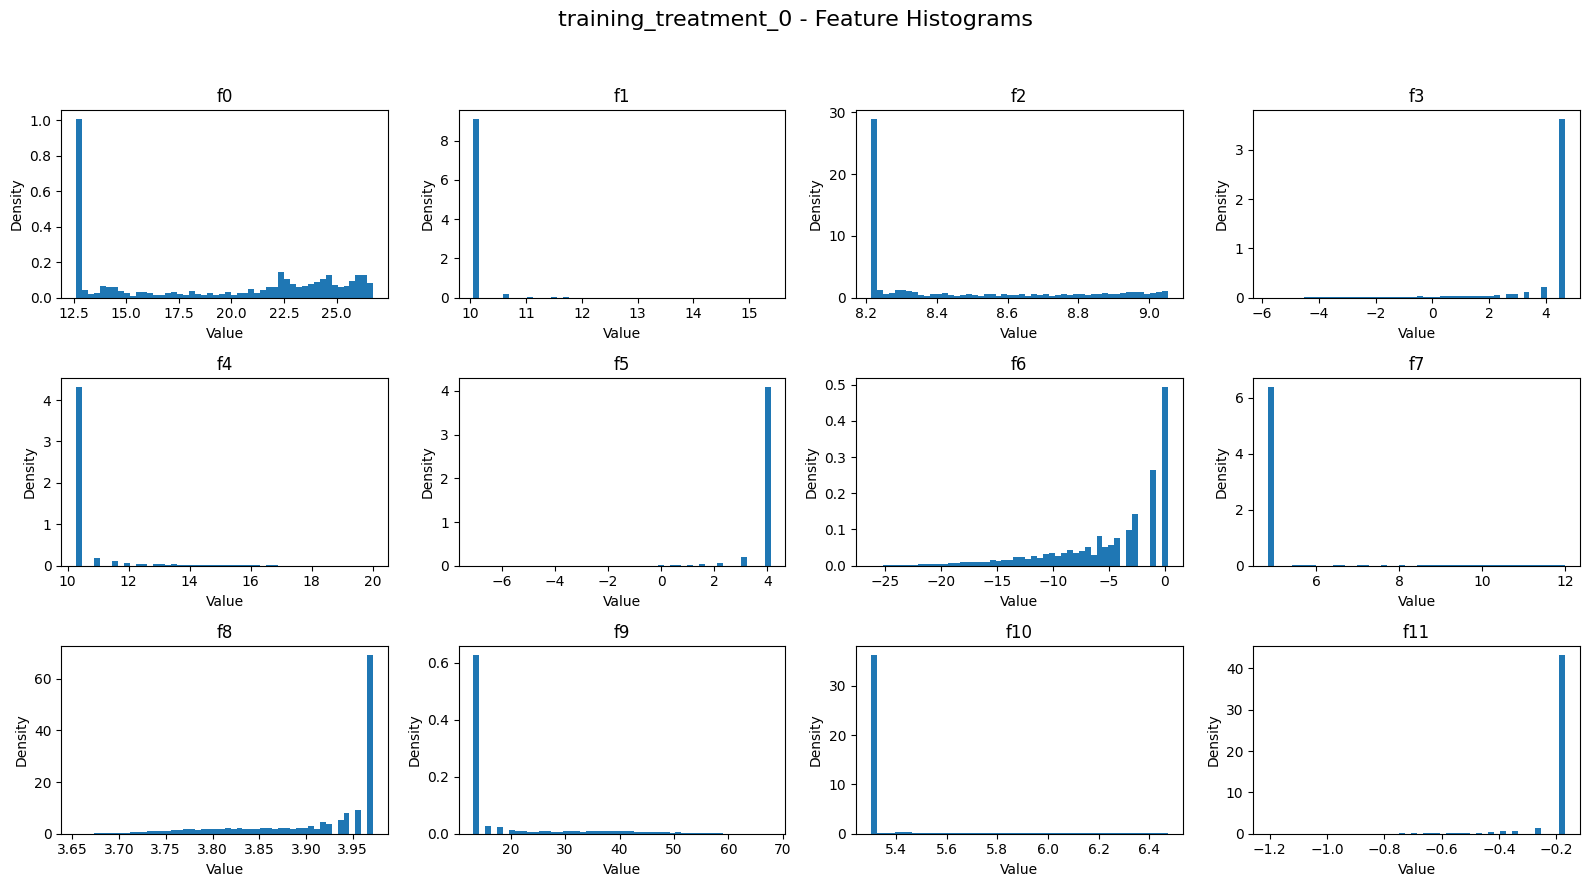

✅ Saved histogram figure to:
D:\IPP_study\Machinelearning\project\pic\histogram_training\training_treatment_0_all_features_histogram.png


In [14]:
# Training Set Histogram
# Path Configuration
DATA_DIR = r"D:\IPP_study\Machinelearning\project\data"
SAVE_DIR = r"D:\IPP_study\Machinelearning\project\pic\histogram_training"

os.makedirs(SAVE_DIR, exist_ok=True)

# Select a training set
FILENAME = "training_treatment_0.csv"   # ← 如需另一个，改成 training_treatment_1.csv
DATASET_NAME = "training_treatment_0"

df = pd.read_csv(os.path.join(DATA_DIR, FILENAME))

# Select only feature columns
feature_cols = [c for c in df.columns if c.startswith("f")]

n_features = len(feature_cols)

# Automatically determine subplot layout
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

# Draw a histogram of the entire plot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=50, density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"{DATASET_NAME} - Feature Histograms", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
save_path = os.path.join(
    SAVE_DIR,
    f"{DATASET_NAME}_all_features_histogram.png"
)

plt.savefig(save_path, dpi=300)
plt.show()
plt.close()

print(f"✅ Saved histogram figure to:\n{save_path}")

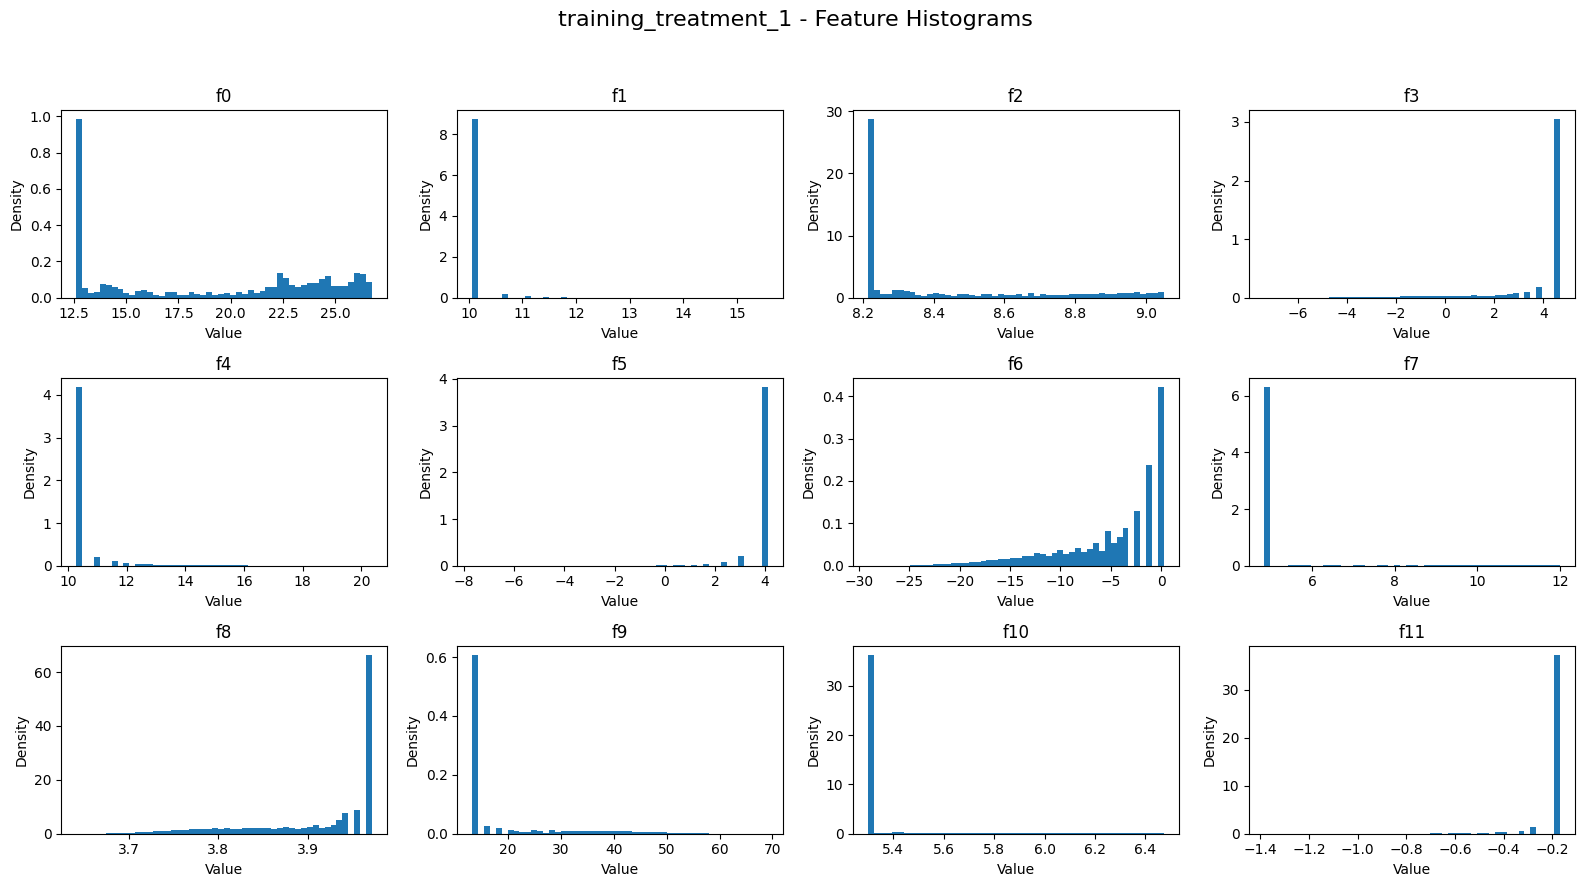

✅ Saved histogram figure to:
D:\IPP_study\Machinelearning\project\pic\histogram_training\training_treatment_1_all_features_histogram.png


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import math

DATA_DIR = r"D:\IPP_study\Machinelearning\project\data"
SAVE_DIR = r"D:\IPP_study\Machinelearning\project\pic\histogram_training"

os.makedirs(SAVE_DIR, exist_ok=True)

FILENAME = "training_treatment_1.csv"  
DATASET_NAME = "training_treatment_1"

df = pd.read_csv(os.path.join(DATA_DIR, FILENAME))

feature_cols = [c for c in df.columns if c.startswith("f")]

n_features = len(feature_cols)

n_cols = 4
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=50, density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"{DATASET_NAME} - Feature Histograms", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

save_path = os.path.join(
    SAVE_DIR,
    f"{DATASET_NAME}_all_features_histogram.png"
)

plt.savefig(save_path, dpi=300)
plt.show()
plt.close()

print(f"✅ Saved histogram figure to:\n{save_path}")

Columns used in correlation:
['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'treatment', 'conversion', 'visit', 'exposure']
Total columns: 16


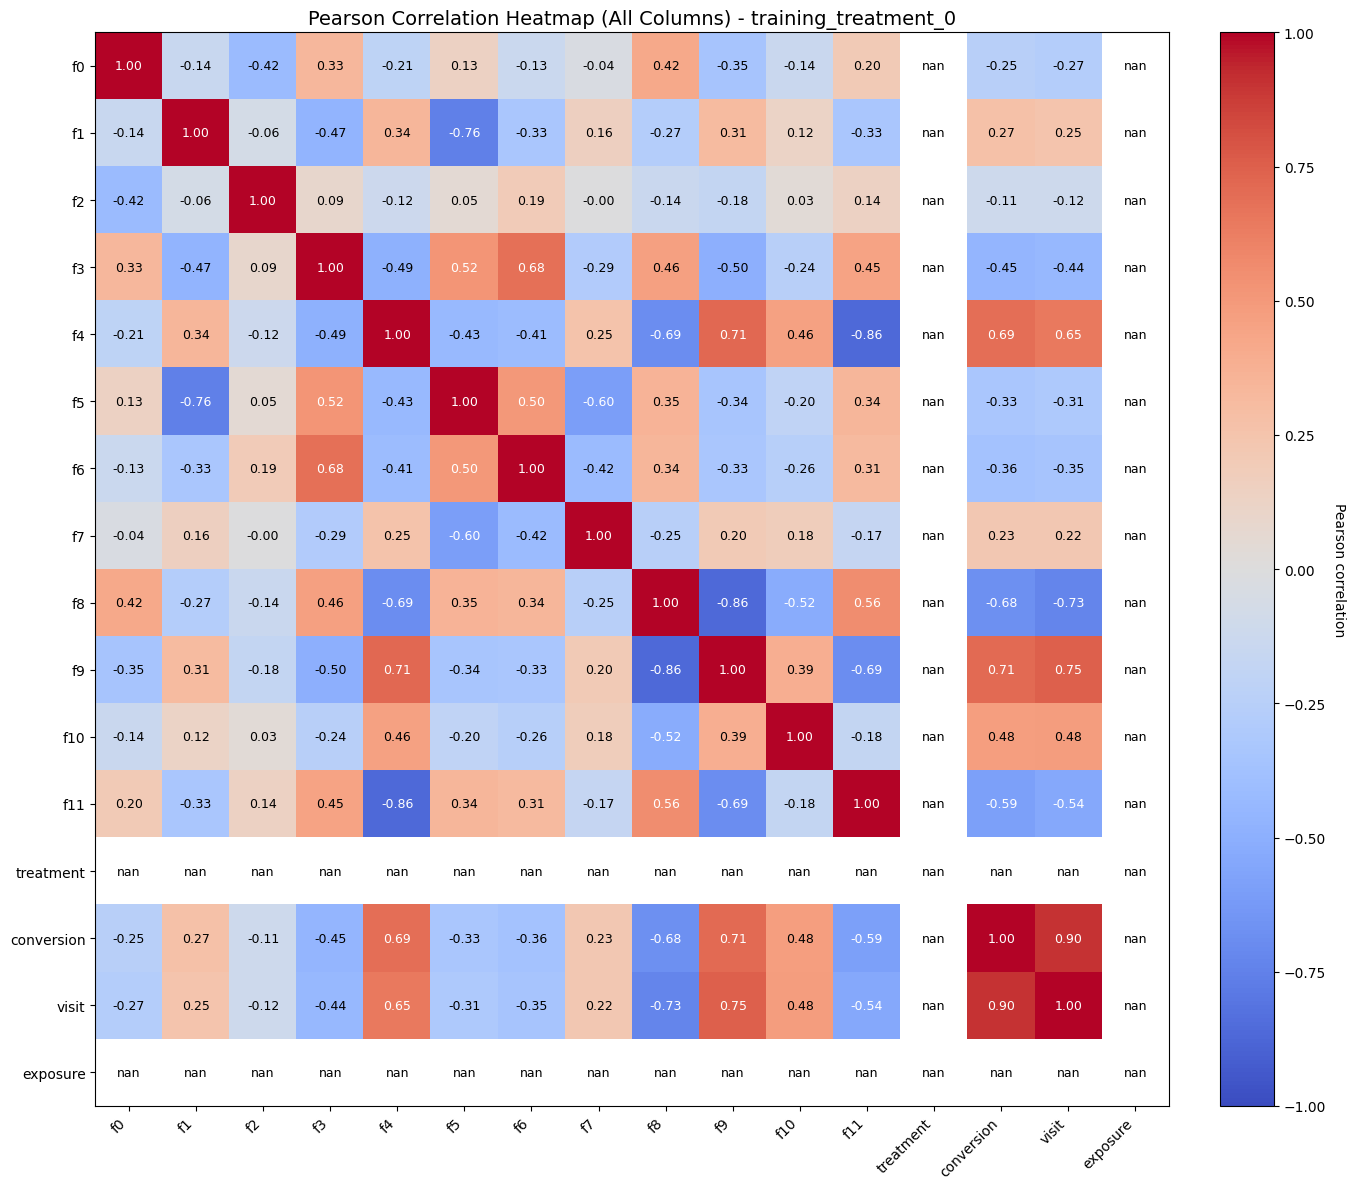


✅ Heatmap saved to:
D:\IPP_study\Machinelearning\project\pic\heatmap\training_treatment_0_pearson_heatmap_ALL_COLUMNS.png


In [22]:
# Heatmap treatment=0
DATA_DIR = r"D:\IPP_study\Machinelearning\project\data"
SAVE_DIR = r"D:\IPP_study\Machinelearning\project\pic\heatmap"
os.makedirs(SAVE_DIR, exist_ok=True)

FILENAME = "training_treatment_0.csv"   
NAME = FILENAME.replace(".csv", "")

df = pd.read_csv(os.path.join(DATA_DIR, FILENAME))

feature_cols = list(df.columns)

print("Columns used in correlation:")
print(feature_cols)
print(f"Total columns: {len(feature_cols)}")

corr = df[feature_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(
    corr.values,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Pearson correlation", rotation=-90, va="bottom")

ax.set_xticks(np.arange(len(feature_cols)))
ax.set_yticks(np.arange(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha="right")
ax.set_yticklabels(feature_cols)

for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        val = corr.iloc[i, j]
        ax.text(
            j, i,
            f"{val:.2f}",
            ha="center",
            va="center",
            color="white" if abs(val) > 0.5 else "black",
            fontsize=9
        )

ax.set_title(f"Pearson Correlation Heatmap (All Columns) - {NAME}", fontsize=14)
plt.tight_layout()

save_path = os.path.join(
    SAVE_DIR,
    f"{NAME}_pearson_heatmap_ALL_COLUMNS.png"
)

plt.savefig(save_path, dpi=300)
plt.show()
plt.close()

print(f"\n✅ Heatmap saved to:\n{save_path}")

Columns used in correlation:
['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'treatment', 'conversion', 'visit', 'exposure']
Total columns: 16


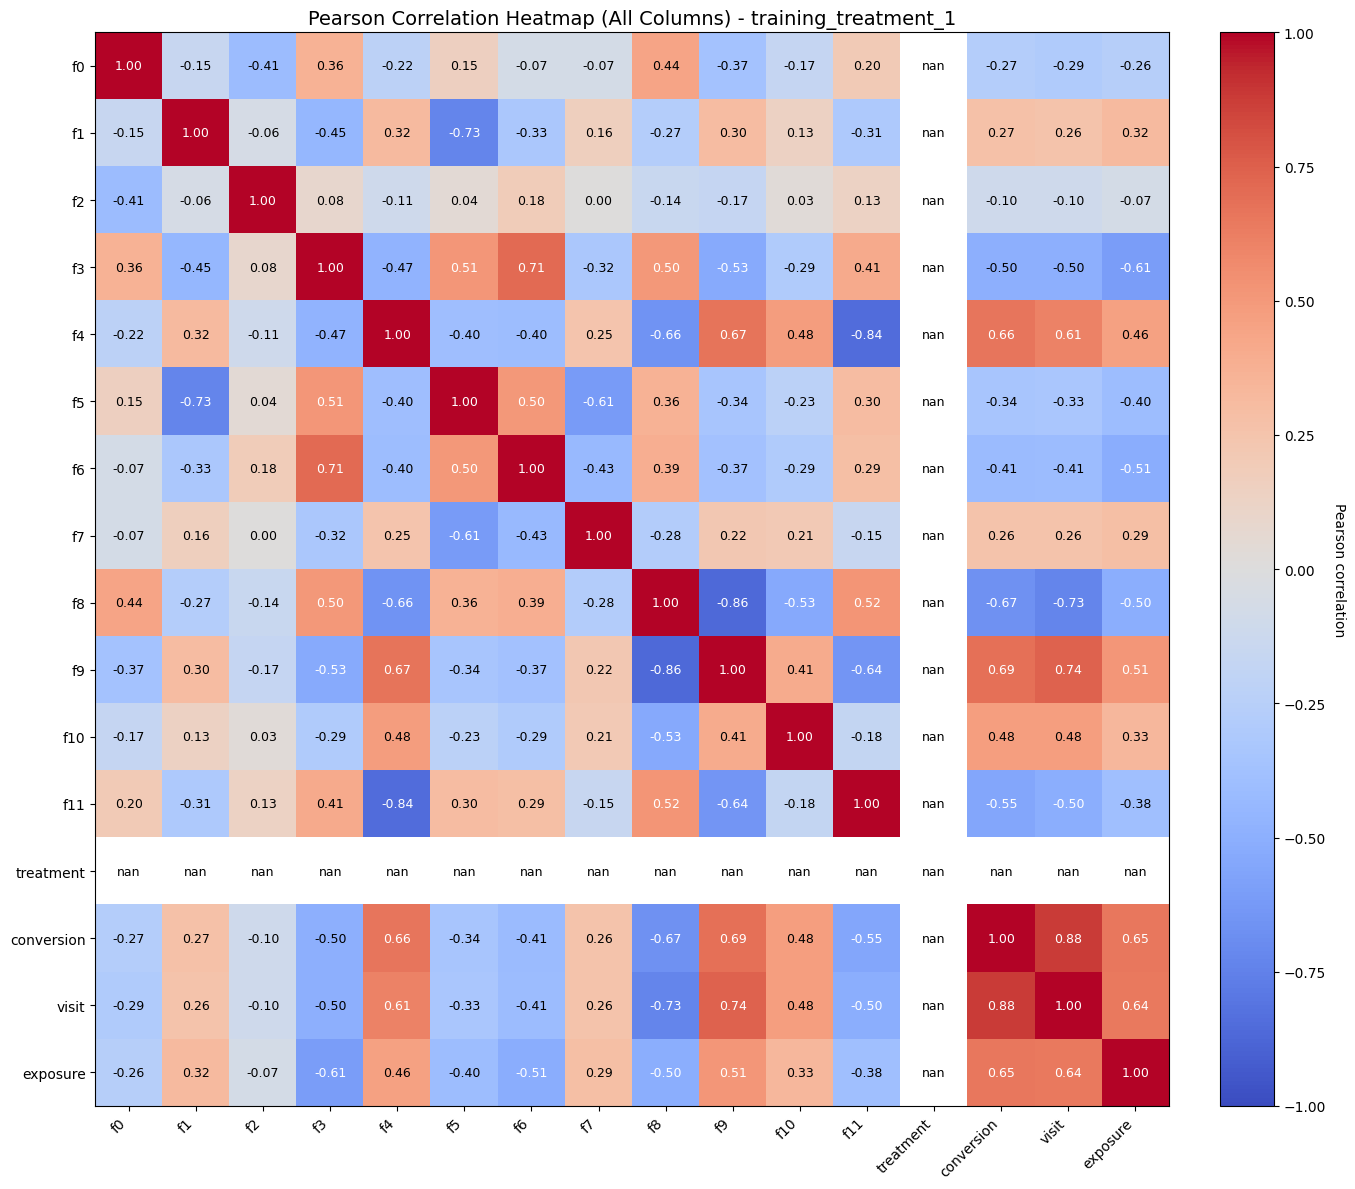


✅ Heatmap saved to:
D:\IPP_study\Machinelearning\project\pic\heatmap\training_treatment_1_pearson_heatmap_ALL_COLUMNS.png


In [23]:
# Heatmap treatment=1
DATA_DIR = r"D:\IPP_study\Machinelearning\project\data"
SAVE_DIR = r"D:\IPP_study\Machinelearning\project\pic\heatmap"
os.makedirs(SAVE_DIR, exist_ok=True)

FILENAME = "training_treatment_1.csv"   
NAME = FILENAME.replace(".csv", "")

df = pd.read_csv(os.path.join(DATA_DIR, FILENAME))

feature_cols = list(df.columns)

print("Columns used in correlation:")
print(feature_cols)
print(f"Total columns: {len(feature_cols)}")

# Pearson correlation
corr = df[feature_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(
    corr.values,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Pearson correlation", rotation=-90, va="bottom")

ax.set_xticks(np.arange(len(feature_cols)))
ax.set_yticks(np.arange(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha="right")
ax.set_yticklabels(feature_cols)

for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        val = corr.iloc[i, j]
        ax.text(
            j, i,
            f"{val:.2f}",
            ha="center",
            va="center",
            color="white" if abs(val) > 0.5 else "black",
            fontsize=9
        )

ax.set_title(f"Pearson Correlation Heatmap (All Columns) - {NAME}", fontsize=14)
plt.tight_layout()

save_path = os.path.join(
    SAVE_DIR,
    f"{NAME}_pearson_heatmap_ALL_COLUMNS.png"
)

plt.savefig(save_path, dpi=300)
plt.show()
plt.close()

print(f"\n✅ Heatmap saved to:\n{save_path}")

In [29]:
# cross validation training for treatment=0
DATA_PATH = r"D:\IPP_study\Machinelearning\project\data\training_treatment_0.csv"
MODEL_DIR = r"D:\IPP_study\Machinelearning\project\model\test0130"
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
feature_cols = [f"f{i}" for i in range(12)]

X = df[feature_cols].values
y = df["conversion"].values

# K-Fold 
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

auc_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
    print(f"\n========== Fold {fold}/{K} ==========")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs",
        n_jobs=-1
    )

    model.fit(X_train_scaled, y_train)
    val_pred = model.predict_proba(X_val_scaled)[:, 1]

    auc = roc_auc_score(y_val, val_pred)
    auc_scores.append(auc)

    print(f"Fold {fold} AUC: {auc:.4f}")

mean_auc = np.mean(auc_scores)
std_auc = np.std(auc_scores)

print("\n========== CV Summary ==========")
print(f"Mean AUC: {mean_auc:.4f}")
print(f"Std  AUC: {std_auc:.4f}")

# Retrain the final model using the entire training set
final_scaler = StandardScaler()
X_scaled_full = final_scaler.fit_transform(X)

final_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
    n_jobs=-1
)

final_model.fit(X_scaled_full, y)

# Save final models
joblib.dump(final_model, os.path.join(MODEL_DIR, "logreg_treatment0_final.joblib"))
joblib.dump(final_scaler, os.path.join(MODEL_DIR, "scaler_treatment0_final.joblib"))

print("\n✅ Final model trained on full dataset and saved.")


========== Fold 1/5 ==========
Fold 1 AUC: 0.9583

========== Fold 2/5 ==========
Fold 2 AUC: 0.9606

========== Fold 3/5 ==========
Fold 3 AUC: 0.9513

========== Fold 4/5 ==========
Fold 4 AUC: 0.9569

========== Fold 5/5 ==========
Fold 5 AUC: 0.9510

========== CV Summary ==========
Mean AUC: 0.9556
Std  AUC: 0.0038

✅ Final model trained on full dataset and saved.


D:\software\anacondainstallenv\envs\machinelearning\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
D:\software\anacondainstallenv\envs\machinelearning\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
D:\software\anacondainstallenv\envs\machinelearning\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
D:\software\anacondainstallenv\envs\machinelearning\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has n

In [31]:
# Ranking feature importance for treatment=0
DATA_PATH = r"D:\IPP_study\Machinelearning\project\data\training_treatment_0.csv"
df = pd.read_csv(DATA_PATH)

feature_cols = [f"f{i}" for i in range(12)]

X = df[feature_cols].values
y = df["conversion"].values

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

baseline_aucs = []
importance_scores = {f: [] for f in feature_cols}

# 4. K-Fold + Permutation Importance
for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
    print(f"\n========== Fold {fold}/{K} ==========")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs"
    )
    model.fit(X_train_scaled, y_train)

    # ---- baseline AUC
    base_pred = model.predict_proba(X_val_scaled)[:, 1]
    base_auc = roc_auc_score(y_val, base_pred)
    baseline_aucs.append(base_auc)

    print(f"Baseline AUC: {base_auc:.4f}")

    # ---- for each feature calculate permutation
    for j, fname in enumerate(feature_cols):
        X_val_perm = X_val_scaled.copy()

        # Only shuffle column j
        X_val_perm[:, j] = shuffle(
            X_val_perm[:, j],
            random_state=fold
        )

        perm_pred = model.predict_proba(X_val_perm)[:, 1]
        perm_auc = roc_auc_score(y_val, perm_pred)

        # AUC decrease = Importance
        importance = base_auc - perm_auc
        importance_scores[fname].append(importance)

print("\n========== Permutation Importance (CV) ==========")

results = []
for f in feature_cols:
    mean_imp = np.mean(importance_scores[f])
    std_imp = np.std(importance_scores[f])
    results.append((f, mean_imp, std_imp))

# Ranked by importance
results.sort(key=lambda x: x[1], reverse=True)

for f, mean_imp, std_imp in results:
    print(
        f"{f:>3s} | "
        f"mean AUC drop = {mean_imp:.5f} | "
        f"std = {std_imp:.5f}"
    )


========== Fold 1/5 ==========
Baseline AUC: 0.9583

========== Fold 2/5 ==========
Baseline AUC: 0.9606

========== Fold 3/5 ==========
Baseline AUC: 0.9513

========== Fold 4/5 ==========
Baseline AUC: 0.9569

========== Fold 5/5 ==========
Baseline AUC: 0.9510

========== Permutation Importance (CV) ==========
 f8 | mean AUC drop = 0.04412 | std = 0.00296
 f4 | mean AUC drop = 0.01503 | std = 0.00254
 f0 | mean AUC drop = 0.00961 | std = 0.00266
 f9 | mean AUC drop = 0.00909 | std = 0.00177
f11 | mean AUC drop = 0.00795 | std = 0.00090
 f6 | mean AUC drop = 0.00427 | std = 0.00115
f10 | mean AUC drop = 0.00257 | std = 0.00026
 f5 | mean AUC drop = 0.00214 | std = 0.00085
 f2 | mean AUC drop = 0.00195 | std = 0.00027
 f7 | mean AUC drop = 0.00170 | std = 0.00031
 f1 | mean AUC drop = 0.00082 | std = 0.00019
 f3 | mean AUC drop = -0.00006 | std = 0.00011


In [32]:
# test treatment = 0
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

MODEL_DIR = r"D:\IPP_study\Machinelearning\project\model\test0130"
TEST_PATH = r"D:\IPP_study\Machinelearning\project\data\treatment_0_test_5_to_1.csv"

MODEL_PATH = os.path.join(MODEL_DIR, "logreg_treatment0_final.joblib")
SCALER_PATH = os.path.join(MODEL_DIR, "scaler_treatment0_final.joblib")

model = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

df_test = pd.read_csv(TEST_PATH)

feature_cols = [f"f{i}" for i in range(12)]

X_test = df_test[feature_cols].values
y_test = df_test["conversion"].values

# Using the training set scaler for transform
X_test_scaled = scaler.transform(X_test)

# Prediction
y_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print("\n========== Test Set Evaluation (treatment = 0) ==========")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")


========== Test Set Evaluation (treatment = 0) ==========
Accuracy : 0.9069
Precision: 0.6744
Recall   : 0.8536
F1-score : 0.7535
ROC-AUC  : 0.9498


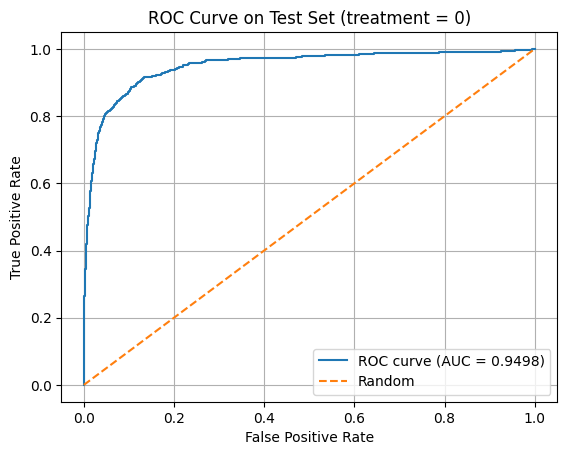

In [34]:
# ROC AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set (treatment = 0)")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
# training treatment = 1
DATA_PATH = r"D:\IPP_study\Machinelearning\project\data\training_treatment_1.csv"
MODEL_DIR = r"D:\IPP_study\Machinelearning\project\model\test0130"
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)

# f0 ~ f11 + exposure
feature_cols = [f"f{i}" for i in range(12)] + ["exposure"]

X = df[feature_cols].values
y = df["conversion"].values

# K-Fold CV
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

auc_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
    print(f"\n========== Fold {fold}/{K} ==========")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # scaler 只在 fold 的训练集上 fit
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs"
    )

    model.fit(X_train_scaled, y_train)
    val_pred = model.predict_proba(X_val_scaled)[:, 1]

    auc = roc_auc_score(y_val, val_pred)
    auc_scores.append(auc)

    print(f"Fold {fold} AUC: {auc:.4f}")


mean_auc = np.mean(auc_scores)
std_auc = np.std(auc_scores)

print("\n========== CV Summary (treatment = 1) ==========")
print(f"Mean AUC: {mean_auc:.4f}")
print(f"Std  AUC: {std_auc:.4f}")

final_scaler = StandardScaler()
X_scaled_full = final_scaler.fit_transform(X)

final_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs"
)

final_model.fit(X_scaled_full, y)

joblib.dump(
    final_model,
    os.path.join(MODEL_DIR, "logreg_treatment1_final.joblib")
)
joblib.dump(
    final_scaler,
    os.path.join(MODEL_DIR, "scaler_treatment1_final.joblib")
)

print("\n✅ Final model (treatment = 1) trained on full dataset and saved.")


========== Fold 1/5 ==========
Fold 1 AUC: 0.9706

========== Fold 2/5 ==========
Fold 2 AUC: 0.9699

========== Fold 3/5 ==========
Fold 3 AUC: 0.9706

========== Fold 4/5 ==========
Fold 4 AUC: 0.9697

========== Fold 5/5 ==========
Fold 5 AUC: 0.9714

========== CV Summary (treatment = 1) ==========
Mean AUC: 0.9704
Std  AUC: 0.0006

✅ Final model (treatment = 1) trained on full dataset and saved.


In [36]:
# feature importance treatment = 1
DATA_PATH = r"D:\IPP_study\Machinelearning\project\data\training_treatment_1.csv"
df = pd.read_csv(DATA_PATH)

# f0 ~ f11 + exposure
feature_cols = [f"f{i}" for i in range(12)] + ["exposure"]

X = df[feature_cols].values
y = df["conversion"].values

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

baseline_aucs = []
importance_scores = {f: [] for f in feature_cols}

for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
    print(f"\n========== Fold {fold}/{K} ==========")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs"
    )
    model.fit(X_train_scaled, y_train)

    base_pred = model.predict_proba(X_val_scaled)[:, 1]
    base_auc = roc_auc_score(y_val, base_pred)
    baseline_aucs.append(base_auc)

    print(f"Baseline AUC: {base_auc:.4f}")

    for j, fname in enumerate(feature_cols):
        X_val_perm = X_val_scaled.copy()

        X_val_perm[:, j] = shuffle(
            X_val_perm[:, j],
            random_state=fold
        )

        perm_pred = model.predict_proba(X_val_perm)[:, 1]
        perm_auc = roc_auc_score(y_val, perm_pred)

        importance = base_auc - perm_auc
        importance_scores[fname].append(importance)

print("\n========== Permutation Importance (CV, treatment = 1) ==========")

results = []
for f in feature_cols:
    mean_imp = np.mean(importance_scores[f])
    std_imp = np.std(importance_scores[f])
    results.append((f, mean_imp, std_imp))

results.sort(key=lambda x: x[1], reverse=True)

for f, mean_imp, std_imp in results:
    print(
        f"{f:>9s} | "
        f"mean AUC drop = {mean_imp:.5f} | "
        f"std = {std_imp:.5f}"
    )


========== Fold 1/5 ==========
Baseline AUC: 0.9706

========== Fold 2/5 ==========
Baseline AUC: 0.9699

========== Fold 3/5 ==========
Baseline AUC: 0.9706

========== Fold 4/5 ==========
Baseline AUC: 0.9697

========== Fold 5/5 ==========
Baseline AUC: 0.9714

========== Permutation Importance (CV, treatment = 1) ==========
 exposure | mean AUC drop = 0.04928 | std = 0.00030
       f8 | mean AUC drop = 0.02928 | std = 0.00086
       f4 | mean AUC drop = 0.00867 | std = 0.00035
      f11 | mean AUC drop = 0.00476 | std = 0.00034
       f9 | mean AUC drop = 0.00438 | std = 0.00057
       f0 | mean AUC drop = 0.00183 | std = 0.00035
      f10 | mean AUC drop = 0.00098 | std = 0.00016
       f3 | mean AUC drop = 0.00072 | std = 0.00030
       f6 | mean AUC drop = 0.00052 | std = 0.00013
       f7 | mean AUC drop = 0.00037 | std = 0.00015
       f5 | mean AUC drop = 0.00034 | std = 0.00010
       f2 | mean AUC drop = 0.00026 | std = 0.00026
       f1 | mean AUC drop = 0.00000 | std = 0

In [37]:
# evaluation treatment = 1
MODEL_DIR = r"D:\IPP_study\Machinelearning\project\model\test0130"
TEST_PATH = r"D:\IPP_study\Machinelearning\project\data\treatment_1_test_5_to_1.csv"

MODEL_PATH = os.path.join(MODEL_DIR, "logreg_treatment1_final.joblib")
SCALER_PATH = os.path.join(MODEL_DIR, "scaler_treatment1_final.joblib")

model = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

df_test = pd.read_csv(TEST_PATH)

# f0 ~ f11 + exposure
feature_cols = [f"f{i}" for i in range(12)] + ["exposure"]

X_test = df_test[feature_cols].values
y_test = df_test["conversion"].values

X_test_scaled = scaler.transform(X_test)

y_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print("\n========== Test Set Evaluation (treatment = 1) ==========")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")


========== Test Set Evaluation (treatment = 1) ==========
Accuracy : 0.9205
Precision: 0.7025
Recall   : 0.9071
F1-score : 0.7918
ROC-AUC  : 0.9697


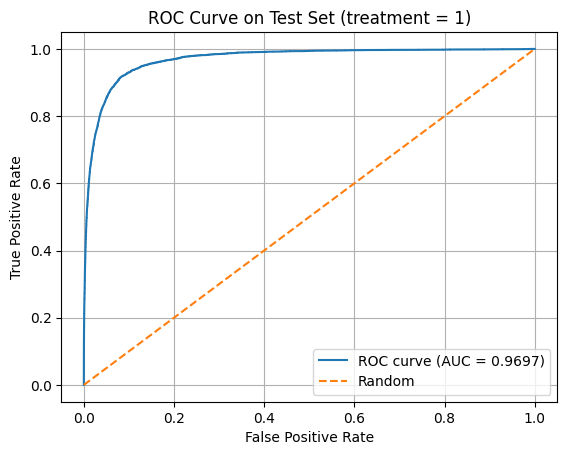

In [38]:
# ROC AUC treatment = 1
MODEL_DIR = r"D:\IPP_study\Machinelearning\project\model\test0130"
TEST_PATH = r"D:\IPP_study\Machinelearning\project\data\treatment_1_test_5_to_1.csv"

MODEL_PATH = os.path.join(MODEL_DIR, "logreg_treatment1_final.joblib")
SCALER_PATH = os.path.join(MODEL_DIR, "scaler_treatment1_final.joblib")

model = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

df_test = pd.read_csv(TEST_PATH)

feature_cols = [f"f{i}" for i in range(12)] + ["exposure"]

X_test = df_test[feature_cols].values
y_test = df_test["conversion"].values

X_test_scaled = scaler.transform(X_test)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set (treatment = 1)")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
# train treatment = 1 without exposure
DATA_PATH = r"D:\IPP_study\Machinelearning\project\data\training_treatment_1.csv"
MODEL_DIR = r"D:\IPP_study\Machinelearning\project\model\test0130"
os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)

# without exposure
feature_cols = [f"f{i}" for i in range(12)]

X = df[feature_cols].values
y = df["conversion"].values

# K-Fold CV
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

auc_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
    print(f"\n========== Fold {fold}/{K} ==========")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # scaler 只在 fold 的训练集上 fit
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs"
    )

    model.fit(X_train_scaled, y_train)
    val_pred = model.predict_proba(X_val_scaled)[:, 1]

    auc = roc_auc_score(y_val, val_pred)
    auc_scores.append(auc)

    print(f"Fold {fold} AUC: {auc:.4f}")

mean_auc = np.mean(auc_scores)
std_auc = np.std(auc_scores)

print("\n========== CV Summary (treatment = 1, NO exposure) ==========")
print(f"Mean AUC: {mean_auc:.4f}")
print(f"Std  AUC: {std_auc:.4f}")

final_scaler = StandardScaler()
X_scaled_full = final_scaler.fit_transform(X)

final_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs"
)

final_model.fit(X_scaled_full, y)

joblib.dump(
    final_model,
    os.path.join(MODEL_DIR, "logreg_treatment1_no_exposure_final.joblib")
)
joblib.dump(
    final_scaler,
    os.path.join(MODEL_DIR, "scaler_treatment1_no_exposure_final.joblib")
)

print("\n✅ Final model (treatment = 1, NO exposure) trained on full dataset and saved.")
print(f"📁 Saved to: {MODEL_DIR}")



========== Fold 1/5 ==========
Fold 1 AUC: 0.9534

========== Fold 2/5 ==========
Fold 2 AUC: 0.9522

========== Fold 3/5 ==========
Fold 3 AUC: 0.9514

========== Fold 4/5 ==========
Fold 4 AUC: 0.9508

========== Fold 5/5 ==========
Fold 5 AUC: 0.9525

========== CV Summary (treatment = 1, NO exposure) ==========
Mean AUC: 0.9521
Std  AUC: 0.0009

✅ Final model (treatment = 1, NO exposure) trained on full dataset and saved.
📁 Saved to: D:\IPP_study\Machinelearning\project\model\test0130


In [41]:
# feature importance for treatment=1 without exposure
print("\n========== Feature Importance Ranking (CV, treatment = 1) ==========")

results = []
for f in feature_cols:
    mean_imp = np.mean(importance_scores[f])
    std_imp = np.std(importance_scores[f])
    results.append({
        "feature": f,
        "mean_auc_drop": mean_imp,
        "std": std_imp
    })

results = sorted(results, key=lambda x: x["mean_auc_drop"], reverse=True)

for rank, r in enumerate(results, start=1):
    print(
        f"{rank:>2d}. {r['feature']:>9s} | "
        f"mean AUC drop = {r['mean_auc_drop']:.5f} | "
        f"std = {r['std']:.5f}"
    )


========== Feature Importance Ranking (CV, treatment = 1) ==========
 1.        f8 | mean AUC drop = 0.04518 | std = 0.00155
 2.        f4 | mean AUC drop = 0.00936 | std = 0.00067
 3.       f11 | mean AUC drop = 0.00884 | std = 0.00060
 4.        f6 | mean AUC drop = 0.00806 | std = 0.00046
 5.        f9 | mean AUC drop = 0.00638 | std = 0.00091
 6.        f0 | mean AUC drop = 0.00594 | std = 0.00054
 7.       f10 | mean AUC drop = 0.00143 | std = 0.00027
 8.        f7 | mean AUC drop = 0.00069 | std = 0.00017
 9.        f2 | mean AUC drop = 0.00060 | std = 0.00031
10.        f5 | mean AUC drop = 0.00049 | std = 0.00015
11.        f3 | mean AUC drop = 0.00006 | std = 0.00009
12.        f1 | mean AUC drop = 0.00006 | std = 0.00006


In [44]:
# uplift evaluation
BASE_DIR = r"D:\IPP_study\Machinelearning\project"

DATA_DIR  = os.path.join(BASE_DIR, "data")
MODEL_DIR = os.path.join(BASE_DIR, "model", "test0130")
OUT_DIR   = os.path.join(BASE_DIR, "result")

os.makedirs(OUT_DIR, exist_ok=True)

# test CSV
TEST_T0 = os.path.join(DATA_DIR, "treatment_0_test_5_to_1.csv")
TEST_T1 = os.path.join(DATA_DIR, "treatment_1_test_5_to_1.csv")

OUT_PATH = os.path.join(OUT_DIR, "uplift_test_mixed_12features.csv")

# Read and mix test data
df_t0 = pd.read_csv(TEST_T0)
df_t1 = pd.read_csv(TEST_T1)

df_all = pd.concat([df_t0, df_t1], axis=0, ignore_index=True)
df_all = df_all.sample(frac=1.0, random_state=42).reset_index(drop=True)

print("Mixed test set shape:", df_all.shape)

# Loading the Model & Scaler
model_t1 = joblib.load(
    os.path.join(MODEL_DIR, "logreg_treatment1_no_exposure_final.joblib")
)
scaler_t1 = joblib.load(
    os.path.join(MODEL_DIR, "scaler_treatment1_no_exposure_final.joblib")
)

model_t0 = joblib.load(
    os.path.join(MODEL_DIR, "logreg_treatment0_final.joblib")
)
scaler_t0 = joblib.load(
    os.path.join(MODEL_DIR, "scaler_treatment0_final.joblib")
)

print("✅ Models loaded successfully.")

# Constructing the "Same X" of Uplift (12 Features)
feature_cols = [f"f{i}" for i in range(12)]
X = df_all[feature_cols].values

print("X shape:", X.shape)  # 必须是 (N, 12)

# Scaling
X_t1_scaled = scaler_t1.transform(X)
X_t0_scaled = scaler_t0.transform(X)

# Predicting Potential Outcomes
p_t1 = model_t1.predict_proba(X_t1_scaled)[:, 1]
p_t0 = model_t0.predict_proba(X_t0_scaled)[:, 1]

# Calculate uplift
uplift = p_t1 - p_t0

uplift_df = df_all.copy()

uplift_df["p_treatment_1"] = p_t1
uplift_df["p_treatment_0"] = p_t0
uplift_df["uplift"] = uplift
uplift_df["recommend_treatment"] = uplift_df["uplift"] > 0

uplift_df["uplift_decile"] = pd.qcut(
    uplift_df["uplift"],
    q=10,
    labels=False
)

uplift_df.to_csv(OUT_PATH, index=False)

print("\n✅ Uplift calculation finished.")
print("Saved to:", OUT_PATH)

print("\nUplift summary:")
print(uplift_df["uplift"].describe())

print("\nMean uplift by decile:")
print(uplift_df.groupby("uplift_decile")["uplift"].mean())


Mixed test set shape: (48930, 16)
✅ Models loaded successfully.
X shape: (48930, 12)

✅ Uplift calculation finished.
Saved to: D:\IPP_study\Machinelearning\project\result\uplift_test_mixed_12features.csv

Uplift summary:
count    48930.000000
mean         0.000099
std          0.025103
min         -0.119059
25%         -0.004775
50%         -0.001402
75%          0.003222
max          0.316512
Name: uplift, dtype: float64

Mean uplift by decile:
uplift_decile
0   -0.043414
1   -0.011990
2   -0.004839
3   -0.003294
4   -0.002130
5   -0.000599
6    0.000666
7    0.003484
8    0.011757
9    0.051351
Name: uplift, dtype: float64


In [46]:
DATA_PATH = r"D:\IPP_study\Machinelearning\project\result\uplift_test_mixed_12features.csv"
OUT_DIR   = r"D:\IPP_study\Machinelearning\project\result\plots"
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)

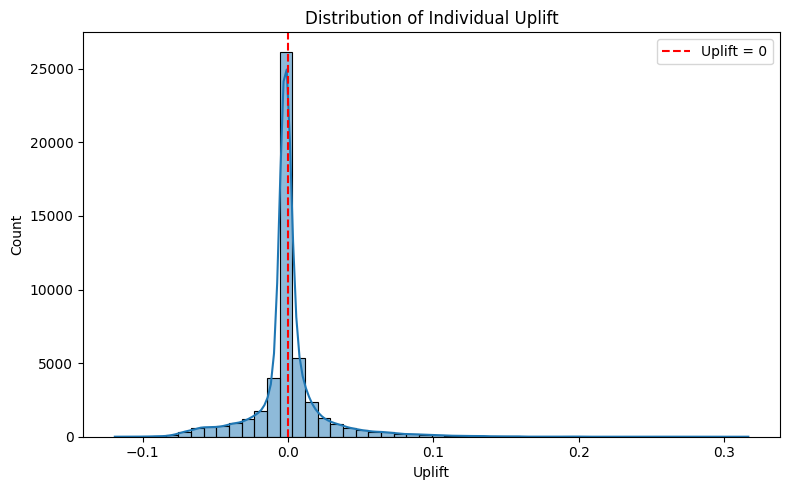

In [47]:
plt.figure(figsize=(8, 5))
sns.histplot(df["uplift"], bins=50, kde=True)

plt.axvline(0, color="red", linestyle="--", label="Uplift = 0")
plt.xlabel("Uplift")
plt.ylabel("Count")
plt.title("Distribution of Individual Uplift")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "uplift_distribution.png"), dpi=300)
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_20972\3498827884.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


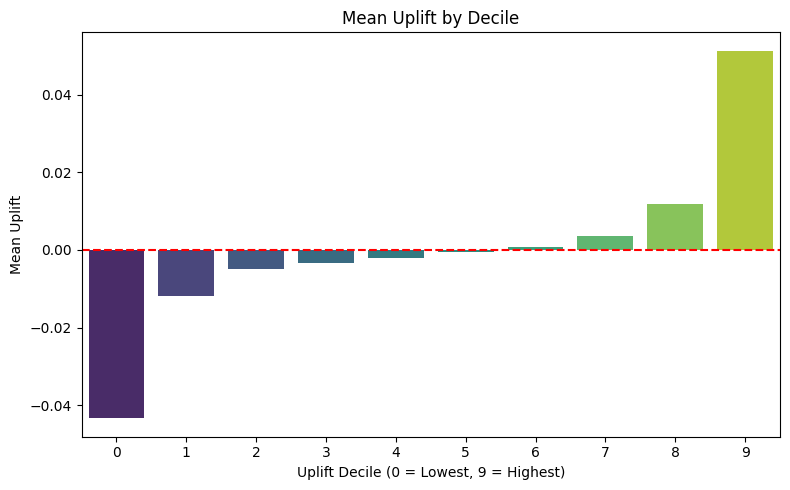

In [48]:
# Calculate decile average uplift
decile_mean = df.groupby("uplift_decile")["uplift"].mean()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=decile_mean.index,
    y=decile_mean.values,
    palette="viridis"
)

plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Uplift Decile (0 = Lowest, 9 = Highest)")
plt.ylabel("Mean Uplift")
plt.title("Mean Uplift by Decile")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "uplift_by_decile.png"), dpi=300)
plt.show()

In [1]:
BASE_FEATURES = [
    "f0","f1","f2","f3","f4","f5",
    "f6","f7","f8","f9","f10","f11"
]

FEATURES_WITH_EXPOSURE = BASE_FEATURES + ["exposure"]

In [4]:
BASE_PATH = r"D:\IPP_study\Machinelearning\project\model\test0130"

# Treatment = 0
scaler_t0 = joblib.load(f"{BASE_PATH}\\scaler_treatment0_final.joblib")
model_t0  = joblib.load(f"{BASE_PATH}\\logreg_treatment0_final.joblib")

# Treatment = 1 (with exposure)
scaler_t1 = joblib.load(f"{BASE_PATH}\\scaler_treatment1_final.joblib")
model_t1  = joblib.load(f"{BASE_PATH}\\logreg_treatment1_final.joblib")

# Treatment = 1 (no exposure)
scaler_t1_noexp = joblib.load(f"{BASE_PATH}\\scaler_treatment1_no_exposure_final.joblib")
model_t1_noexp  = joblib.load(f"{BASE_PATH}\\logreg_treatment1_no_exposure_final.joblib")

In [5]:
DATA_PATH = r"D:\IPP_study\Machinelearning\project\data"

df_t0 = pd.read_csv(f"{DATA_PATH}\\treatment_0_sample_1_5.csv")
df_t1 = pd.read_csv(f"{DATA_PATH}\\treatment_1_sample_1_5.csv")

In [6]:
assert set(BASE_FEATURES).issubset(df_t0.columns)
assert set(BASE_FEATURES).issubset(df_t1.columns)
assert "exposure" in df_t1.columns
assert "conversion" in df_t0.columns
assert "conversion" in df_t1.columns

In [7]:
from matplotlib.colors import LogNorm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)


def evaluate_model(y_true, y_prob, threshold=0.5, title_suffix=""):
    """
    Evaluate a binary classifier and plot ROC curve + confusion matrix (LogNorm).

    Parameters
    ----------
    y_true : array-like
        True labels (0/1)
    y_prob : array-like
        Predicted probabilities for the positive class
    threshold : float
        Classification threshold
    title_suffix : str
        Suffix to add to plot titles
    """

    # ===== Binary prediction =====
    y_pred = (y_prob >= threshold).astype(int)

    # ===== Metrics =====
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)

    print(f"\n========== Test Set Evaluation {title_suffix} ==========")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    # ===== ROC Curve =====
    fpr, tpr, _ = roc_curve(y_true, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate", fontsize=11)
    plt.ylabel("True Positive Rate", fontsize=11)
    plt.title(f"ROC Curve {title_suffix}", fontsize=13, pad=10)
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    cm = confusion_matrix(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)

    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Proportion")
    
    labels = [["TN", "FP"], ["FN", "TP"]]
    values = cm
    
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                f"{labels[i][j]}\n{values[i,j]:,}\n({cm_norm[i,j]*100:.2f}%)",
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold",
                color="black"
            )
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Negative", "Pred Positive"])
    ax.set_yticklabels(["Actual Negative", "Actual Positive"])
    ax.set_title("Confusion Matrix (Row-normalized)")
    plt.tight_layout()
    plt.show()

In [8]:
from sklearn.metrics import accuracy_score

D:\software\anacondainstallenv\envs\machinelearning\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



========== Test Set Evaluation (treatment = 0) ==========
Accuracy : 0.9168
Precision: 0.0196
Recall   : 0.8536
F1-score : 0.0383
ROC-AUC  : 0.9496


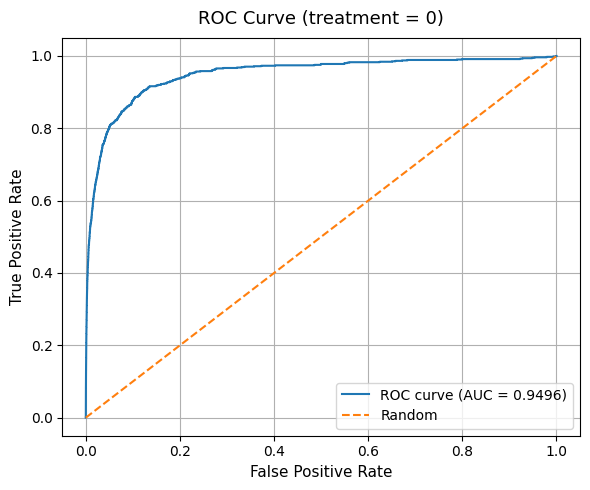

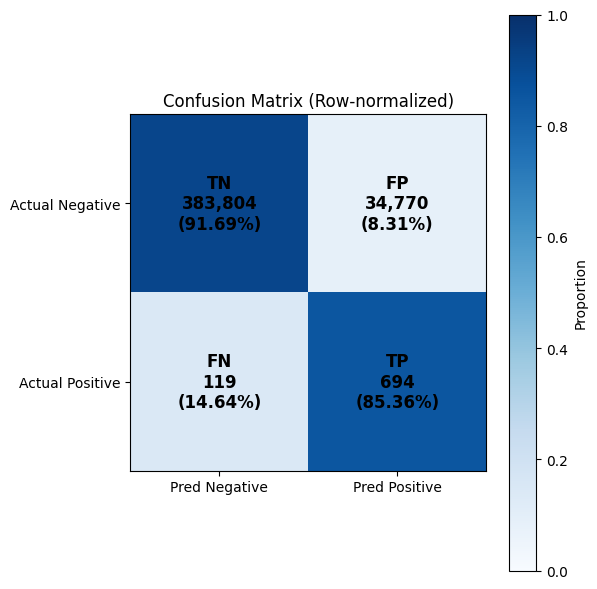

ROC curve saved to: D:\IPP_study\Machinelearning\project\pic\0210\roc_curve_treatment_0.png


In [10]:
# Evaluation for treatment=0 without downsampling the test set
X_t0 = df_t0[BASE_FEATURES]
X_t0_scaled = scaler_t0.transform(X_t0)

df_t0["pred_prob"] = model_t0.predict_proba(X_t0_scaled)[:, 1]

evaluate_model(
    y_true=df_t0["conversion"].values,
    y_prob=df_t0["pred_prob"].values,
    threshold=0.5,
    title_suffix="(treatment = 0)"
)

D:\software\anacondainstallenv\envs\machinelearning\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



========== Test Set Evaluation (treatment = 1, with exposure) ==========
Accuracy : 0.9234
Precision: 0.0354
Recall   : 0.9071
F1-score : 0.0682
ROC-AUC  : 0.9701


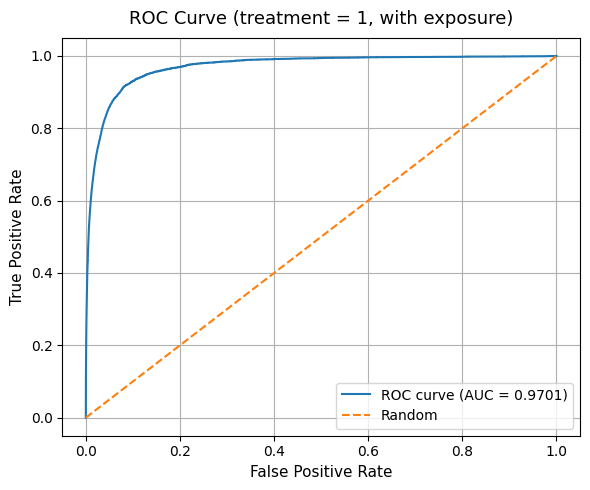

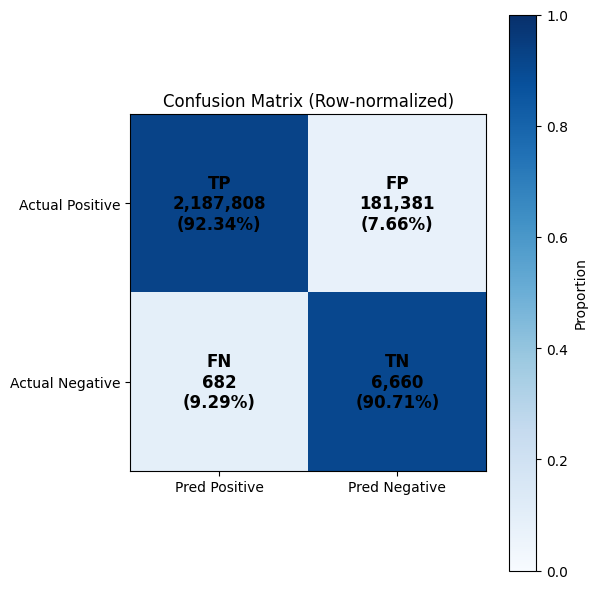

In [25]:
# Evaluation for treatment=1 without downsampling the test set with exposure
X_t1 = df_t1[FEATURES_WITH_EXPOSURE]
X_t1_scaled = scaler_t1.transform(X_t1)

df_t1["pred_prob_with_exposure"] = model_t1.predict_proba(X_t1_scaled)[:, 1]

evaluate_model(
    y_true=df_t1["conversion"].values,
    y_prob=df_t1["pred_prob_with_exposure"].values,
    threshold=0.5,
    title_suffix="(treatment = 1, with exposure)"
)

D:\software\anacondainstallenv\envs\machinelearning\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



========== Test Set Evaluation (treatment = 1, no exposure) ==========
Accuracy : 0.9093
Precision: 0.0287
Recall   : 0.8642
F1-score : 0.0556
ROC-AUC  : 0.9519


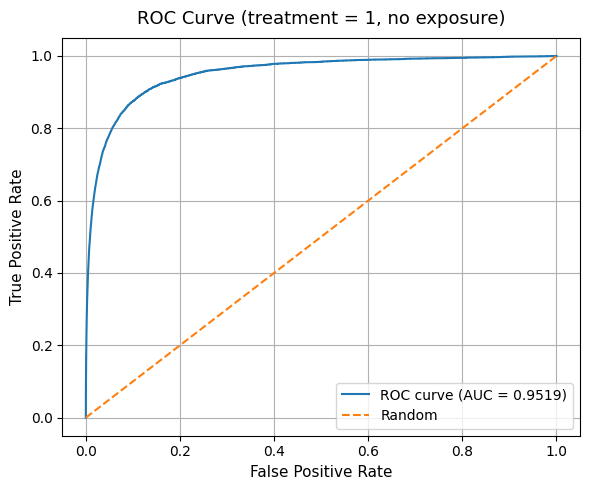

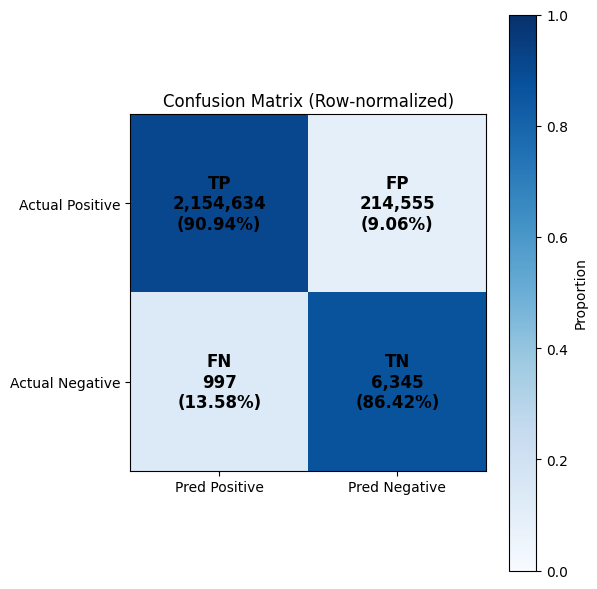

In [26]:
# Evaluation for treatment=1 without downsampling the test set without exposure
X_t1_noexp = df_t1[BASE_FEATURES]
X_t1_noexp_scaled = scaler_t1_noexp.transform(X_t1_noexp)

df_t1["pred_prob_no_exposure"] = model_t1_noexp.predict_proba(X_t1_noexp_scaled)[:, 1]

evaluate_model(
    y_true=df_t1["conversion"].values,
    y_prob=df_t1["pred_prob_no_exposure"].values,
    threshold=0.5,
    title_suffix="(treatment = 1, no exposure)"
)